<a href="https://colab.research.google.com/github/1RakshitPatil/Handwritten_Character_Recognition/blob/main/HANDWRITTEN_USING_BACK_PROPOGATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [76]:
df= pd.read_csv('/content/A_Z Handwritten Data.csv').astype('float32')

In [77]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
df.sample(5)

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
66979,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
206678,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196408,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
349364,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47013,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
df.shape

X = df.drop('0',axis = 1)
y = df['0']

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [81]:
#normalize data
x_train = x_train/255
x_test = x_test/255
print(x_train.shape)
print(x_test.shape)


(297960, 784)
(74490, 784)


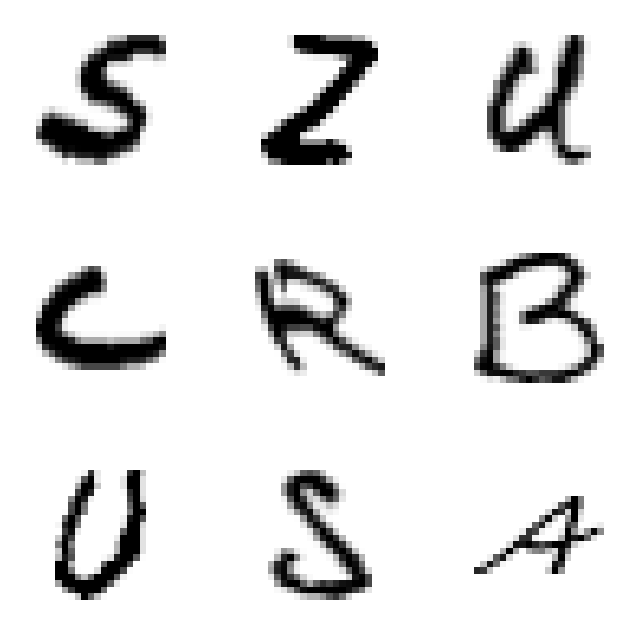

In [82]:
#visualize data
import cv2
shuffle_data=shuffle(x_train.values)
fig,axes=plt.subplots(3,3,figsize=(8,8))
axes=axes.flatten()

for i in range(9):
  axes[i].imshow(np.reshape(shuffle_data[i],(28,28)), cmap="Grays")
  axes[i].axis('off')
plt.show()

In [83]:
#one hot encoding
from tensorflow.keras.utils import to_categorical
y_testing=to_categorical(y_train.astype('int'), num_classes=26)
y_training=to_categorical(y_test.astype('int'), num_classes=26)

In [84]:
#build fnn
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
#INPUT LAYER
model.add(Dense(256, activation='relu', input_shape=(784,)))
#HIDDEN LAYER
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
#OUTPUT LAYER
model.add(Dense(26, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,802 (952.35 KB)

 Trainable params: 243,802 (952.35 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
history = model.fit(
    x_train, y_testing, # Swapped y_training with y_testing
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_training) # Swapped y_testing with y_training
)

Epoch 1/5
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9326 - loss: 0.2370 - val_accuracy: 0.9657 - val_loss: 0.1170
Epoch 2/5
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.9706 - loss: 0.0995 - val_accuracy: 0.9727 - val_loss: 0.0935
Epoch 3/5
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9778 - loss: 0.0735 - val_accuracy: 0.9743 - val_loss: 0.0867
Epoch 4/5
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.9820 - loss: 0.0588 - val_accuracy: 0.9790 - val_loss: 0.0733
Epoch 5/5
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9818 - val_loss: 0.0673


In [92]:
# 9. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_training)
print("Test Accuracy:", test_acc)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9818 - loss: 0.0673
Test Accuracy: 0.9818499088287354


In [93]:
model.save('ffnn_handwritten_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


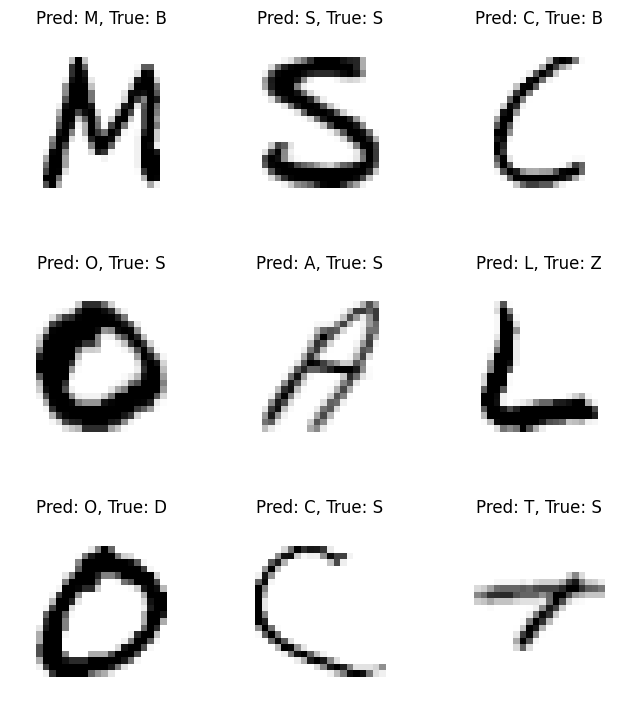

In [94]:
# 11. Prediction Visualization
words = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',
         9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',
         17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}

fig, axes = plt.subplots(3,3, figsize=(8,9))
axes = axes.flatten()

predictions = model.predict(x_test[:9])

for i, ax in enumerate(axes):
    image = np.reshape(x_test.values[i], (28,28))
    ax.imshow(image, cmap="Greys")

    pred_label = words[np.argmax(predictions[i])]
    true_label = words[np.argmax(y_testing[i])]

    ax.set_title(f"Pred: {pred_label}, True: {true_label}")
    ax.axis('off')

plt.show()

In [95]:
import cv2
from tensorflow.keras.models import load_model

model = load_model('ffnn_handwritten_model.h5')

image = cv2.imread('/content/K.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.resize(image, (28,28))

# Invert & normalize
image = 255 - image
image = image / 255.0

# Flatten for FFNN
image = image.reshape(1, 784)

prediction = words[np.argmax(model.predict(image))]

print("Predicted Character:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Predicted Character: K


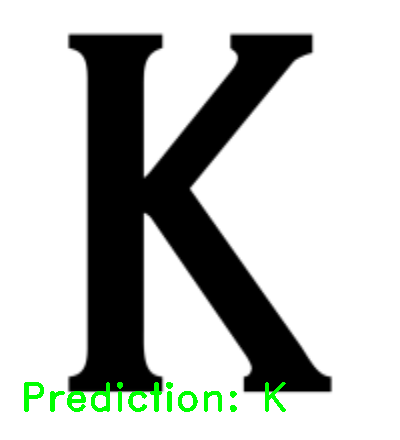

In [96]:
import cv2
from google.colab.patches import cv2_imshow

# The 'prediction' variable from the previous cell is correctly 'A'.

# Reload the original image specifically for display purposes.
display_image = cv2.imread('K.png')

if display_image is None:
    print("Error: Could not load image 'E.png'. Please ensure the file exists.")
else:
    # Ensure the image is in a 3-channel format suitable for cv2.putText with color.
    # If the image is grayscale (2D array), convert it to BGR.
    if len(display_image.shape) == 2:
        display_image = cv2.cvtColor(display_image, cv2.COLOR_GRAY2BGR)
    # If the image has 4 channels (e.g., RGBA), convert to BGR.
    elif display_image.shape[2] == 4:
        display_image = cv2.cvtColor(display_image, cv2.COLOR_BGRA2BGR)

    # Convert from BGR (OpenCV default) to RGB for consistent display with many tools.
    # cv2_imshow typically handles BGR, but RGB is a safer general practice.
    display_image = cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)

    # Resize the image for better visualization, as originally intended.
    display_image = cv2.resize(display_image, (400, 440))

    # Add the prediction text to the image. The 'prediction' variable holds the correct result.
    # Text color (0, 255, 0) is green in RGB.
    cv2.putText(display_image, "Prediction: " + prediction, (20, 410), cv2.FONT_HERSHEY_DUPLEX, 1.3, (0, 255, 0), 2)

    # Display the image.
    cv2_imshow(display_image)
